# Autoencoder -- One-Class Classification

## Goal

The model learns **only good rowing strokes**. It then decides:
> Is this new stroke similar enough to what I have learned?

This is a **One-Class Classification** problem (anomaly detection).
- Class 0 (Normal): good stroke
- Everything else: bad stroke (anomaly)

---

## What is an Autoencoder?

An autoencoder is a neural network with two parts:

```
Input --> [ENCODER] --> Bottleneck --> [DECODER] --> Reconstruction
```

- **Encoder**: compresses the input into a small bottleneck representation
- **Decoder**: reconstructs the input from the bottleneck
- **Loss**: MSE between input and reconstruction

Good strokes are reconstructed well. Bad strokes produce a high reconstruction error -- that is the detection signal.

---

## Why LSTM?

LSTM remembers past time steps (memory), making it well suited for sequences where the overall rhythm matters -- here: catch → drive → finish across the full stroke. A Conv1D would only detect local patterns within a short window.

## Setup

**Cell 1** installs all required packages. Run this once; skip on subsequent runs if packages are already installed.

**Cell 2** imports all libraries and sets three global configurations:
- `RANDOM_STATE` — fixed seed for NumPy and TensorFlow so results are reproducible across runs
- `optuna.logging.set_verbosity` — suppresses Optuna's per-trial log output; only warnings are shown
- `PROJECT_ROOT` / `NORM_DIR` — resolves file paths relative to the project root so the notebook works regardless of which directory it is launched from

In [73]:
!pip install tensorflow optuna -q


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'

print('TensorFlow:', tf.__version__)
print('Project root:', PROJECT_ROOT)


TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


## Data Loading and Preprocessing

The LSTM Autoencoder has three requirements that this code fulfills:

1. **Fixed input shape** — strokes vary in length (e.g. 19–23 frames). All sequences are resampled to a single `TARGET_LEN` so Keras receives a uniform 3D array.
2. **Numbers only** — the CSV also contains metadata columns (`phase`, `GOOD`, `BAD`). These are excluded so the model learns to reconstruct movement, not labels.
3. **Good and bad separated** — the autoencoder trains on good strokes only (`X_good_seq`). Bad strokes (`X_bad_seq`) are held back for evaluation: because the model has never seen them, it reconstructs them poorly — and that high reconstruction error is the detection signal.

In [75]:
EXCLUDE_COLS = {'phase', 'GOOD', 'BAD'}

def resample_seq(seq, target_len):
    x_old = np.linspace(0, 1, len(seq))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, seq, axis=0)(x_new)

def load_strokes_for_video(video_stem): 
    lm_path     = NORM_DIR / f'{video_stem}-landmarks-norm_10fps.csv'
    stroke_path = NORM_DIR / f'{video_stem}-strokes.csv'
    landmarks   = pd.read_csv(lm_path)
    strokes     = pd.read_csv(stroke_path)
    feature_cols = [c for c in landmarks.columns if c not in EXCLUDE_COLS]
    X = landmarks[feature_cols].values

    # strokes.csv stores frame numbers from the original video (~30fps).
    # The landmarks file is downsampled to 10fps (~factor 3).
    fps_ratio = max(1, round(strokes['endzug_end'].max() / len(landmarks)))

    seqs = []
    for _, row in strokes.iterrows():
        start = int(row['endzug_start'] / fps_ratio)
        end   = int(row['endzug_end']   / fps_ratio)
        seq   = X[start:end]
        if len(seq) >= 10:
            seqs.append(seq)
    return seqs, feature_cols, fps_ratio

# --- Load all stroke files ---
stroke_files = sorted(NORM_DIR.glob('*-strokes.csv'))
# stroke_files = [f for f in stroke_files if not f.stem.startswith('sim')]  # exclude Simon's videos

# Single pass: load raw sequences, collect lengths, print summary
raw          = {}   # video_stem -> (seqs, feature_cols, fps_ratio)
all_lengths  = []
feature_cols = None

print(f'Videos found: {len(stroke_files)}')
for sf in stroke_files:
    video_stem = sf.stem.replace('-strokes', '')
    label = 'BAD ' if 'BAD' in video_stem.upper() else 'GOOD'
    seqs, fcols, ratio = load_strokes_for_video(video_stem)
    if feature_cols is None:
        feature_cols = fcols
    raw[video_stem] = (seqs, ratio)
    all_lengths.extend(len(s) for s in seqs)
    print(f'  [{label}]  {video_stem}: {len(seqs)} strokes (fps_ratio={ratio})')

TARGET_LEN = int(np.median(all_lengths))
print(f'\nStroke lengths (10fps) -- min: {min(all_lengths)}  median: {TARGET_LEN}  max: {max(all_lengths)}')
print(f'TARGET_LEN = {TARGET_LEN} frames')

# Resample and sort into good / bad
good_seqs, bad_seqs = [], []
for video_stem, (seqs, _) in raw.items():
    resampled = [resample_seq(s, TARGET_LEN) for s in seqs]
    if 'BAD' in video_stem.upper():
        bad_seqs.extend(resampled)
    else:
        good_seqs.extend(resampled) 

X_good_seq = np.array(good_seqs)
X_bad_seq  = np.array(bad_seqs)

print(f'\nGood strokes: {X_good_seq.shape}  (n_sequences, frames, features)')
print(f'Bad strokes:  {X_bad_seq.shape}')


Videos found: 10
  [BAD ]  cla-BAD-2: 59 strokes (fps_ratio=3)
  [BAD ]  cla-BAD: 20 strokes (fps_ratio=3)
  [GOOD]  cla-GOOD-fast: 87 strokes (fps_ratio=3)
  [GOOD]  cla-GOOD-slow-2: 33 strokes (fps_ratio=3)
  [GOOD]  cla-GOOD-slow: 68 strokes (fps_ratio=3)
  [GOOD]  mar-GOOD-fast: 61 strokes (fps_ratio=3)
  [GOOD]  mar-GOOD-slow: 50 strokes (fps_ratio=3)
  [GOOD]  sim-GOOD-fast: 45 strokes (fps_ratio=3)
  [GOOD]  sim-GOOD-slow: 76 strokes (fps_ratio=3)
  [GOOD]  sim-GOOD-slow2: 11 strokes (fps_ratio=3)

Stroke lengths (10fps) -- min: 18  median: 26  max: 34
TARGET_LEN = 26 frames

Good strokes: (431, 26, 66)  (n_sequences, frames, features)
Bad strokes:  (79, 26, 66)


## Normalization Check

The Mediapipe normalization expresses all landmark coordinates relative to the body — so no additional StandardScaler is needed. However, before training it is worth verifying two things:

1. **Values are in a reasonable range** — not hundreds or thousands, which would destabilize training.
2. **Good and bad strokes are on the same scale** — if they differed, the model would see a distribution shift between training and evaluation, and the reconstruction error would reflect scale differences rather than movement quality.

The mean does not need to be exactly 0 — a systematic offset is expected because most landmarks sit below the Mediapipe reference point. What matters is that both groups share the same offset.

In [76]:
mean_good, std_good = X_good_seq.mean().round(4), X_good_seq.std().round(4)
mean_bad,  std_bad  = X_bad_seq.mean().round(4),  X_bad_seq.std().round(4)

print(f'Good strokes -- Mean: {mean_good}  Std: {std_good}')
print(f'Bad strokes  -- Mean: {mean_bad}   Std: {std_bad}')

# --- Automated interpretation ---
mean_diff = abs(mean_good - mean_bad)
std_diff  = abs(std_good  - std_bad)
scale_ok  = max(abs(mean_good), abs(mean_bad)) < 5 and max(std_good, std_bad) < 5
align_ok  = mean_diff < 0.1 and std_diff < 0.1

print()
if scale_ok:
    print('OK  Values are in a reasonable range -- no StandardScaler needed.')
else:
    print('WARN  Values are large -- consider adding a StandardScaler.')

if align_ok:
    print(f'OK  Good and bad strokes are on the same scale '
          f'(mean diff={mean_diff:.4f}, std diff={std_diff:.4f}).')
else:
    print(f'WARN  Scale mismatch between good and bad strokes '
          f'(mean diff={mean_diff:.4f}, std diff={std_diff:.4f}) -- '
          f'reconstruction error may reflect scale, not movement quality.')


Good strokes -- Mean: -0.4573  Std: 0.6426
Bad strokes  -- Mean: -0.4498   Std: 0.6214

OK  Values are in a reasonable range -- no StandardScaler needed.
OK  Good and bad strokes are on the same scale (mean diff=0.0075, std diff=0.0212).


## Train / Validation / Test Split

The autoencoder trains **only on good strokes** — it must never see a bad stroke during training, otherwise it would learn to reconstruct those too and lose its detection ability.

Before splitting, the sequences are shuffled randomly. This is necessary because `X_good_seq` is ordered by video: all strokes from video 1, then video 2, and so on. Without shuffling, the validation and test sets would contain only strokes from the last video(s).

The split is 70 / 15 / 15:
- **X_train** — used to train the model (70%)
- **X_val** — used by early stopping to decide when to stop training (15%)
- **X_test_good** — held-out good strokes for final evaluation (15%)
- **X_bad_seq** — all bad strokes, combined with `X_test_good` at evaluation time

The key distinction: `X_val` influences training (early stopping reads it after every epoch). `X_test_good` is never seen during training and gives an unbiased performance estimate.

In [77]:
stroke_indices  = np.random.permutation(len(X_good_seq))
X_good_shuffled = X_good_seq[stroke_indices]

n_train = int(len(X_good_shuffled) * 0.70)
n_val   = int(len(X_good_shuffled) * 0.15)

X_train     = X_good_shuffled[:n_train]
X_val       = X_good_shuffled[n_train:n_train + n_val]
X_test_good = X_good_shuffled[n_train + n_val:]

print(f'Train:            {X_train.shape[0]} sequences')
print(f'Validation:       {X_val.shape[0]} sequences  (early stopping only)')
print(f'Test (good):      {X_test_good.shape[0]} sequences')
print(f'Test (bad):       {X_bad_seq.shape[0]} sequences')
print(f'Test (total):     {X_test_good.shape[0] + X_bad_seq.shape[0]} sequences')


Train:            301 sequences
Validation:       64 sequences  (early stopping only)
Test (good):      66 sequences
Test (bad):       79 sequences
Test (total):     145 sequences


## LSTM Autoencoder -- Architecture

| Layer | Output shape | Role |
|---|---|---|
| Input | `(24, 66)` | one stroke |
| LSTM(128) | `(128,)` | encode sequence → single vector |
| Dense(32) | `(32,)` | bottleneck |
| RepeatVector(24) | `(24, 32)` | broadcast bottleneck across time |
| LSTM(128, return_sequences) | `(24, 128)` | decode |
| TimeDistributed(Dense(66)) | `(24, 66)` | reconstruct each frame |

**Loss**: MSE(input, reconstruction) -- **Anomaly score**: mean MSE per sequence.

In [78]:
n_timesteps = TARGET_LEN
n_features  = X_train.shape[2]
LATENT_DIM  = 32

def build_lstm_autoencoder(timesteps, features, latent_dim):
    inputs = keras.Input(shape=(timesteps, features), name='input')

    # Encoder
    x = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.RepeatVector(timesteps, name='repeat')(bottleneck)
    x = layers.LSTM(128, return_sequences=True, name='decoder_lstm')(x)
    outputs = layers.TimeDistributed(layers.Dense(features), name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Autoencoder')

model = build_lstm_autoencoder(n_timesteps, n_features, LATENT_DIM)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 26, 66)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 26, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 26, 66)         │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,914 (761.38 KB)

 Trainable params: 194,914 (761.38 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,            # Autoencoder: Input = Target
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3589 - val_loss: 0.1355
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1014 - val_loss: 0.0917
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0835 - val_loss: 0.0775
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0715 - val_loss: 0.0700
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0641 - val_loss: 0.0621
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0576 - val_loss: 0.0575
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0541 - val_loss: 0.0549
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0516 - val_loss: 0.0504
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0434 - val_loss: 0.0328
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0252 - val_loss: 0.0160
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179 - val_loss: 0.0239
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

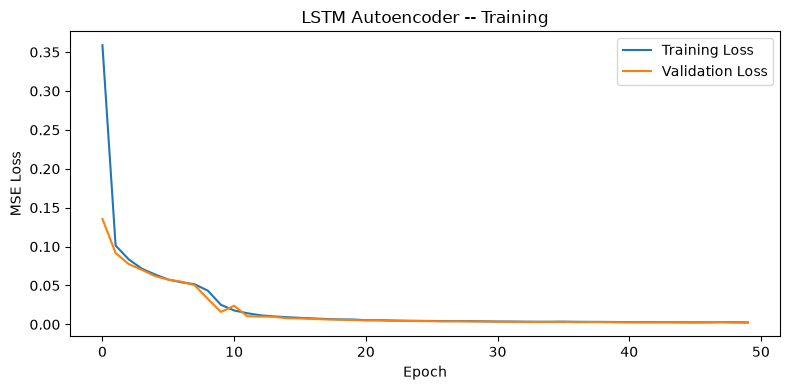

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder -- Training')
ax.legend()
plt.tight_layout()
plt.show()


## Threshold

We compute the reconstruction error (MSE) for all training sequences.
As the threshold we use the **95th percentile** of training errors:

> Sequences with MSE > Threshold --> **bad stroke**

The threshold can be adjusted (e.g. 99th percentile = stricter, fewer false positives).


In [81]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors     = reconstruction_error(model, X_train)
test_good_errors = reconstruction_error(model, X_test_good)
bad_errors       = reconstruction_error(model, X_bad_seq)

THRESHOLD_PERCENTILE = 95
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}th percentile of training errors): {threshold:.6f}')
print(f'Mean error -- Train:      {train_errors.mean():.6f}')
print(f'Mean error -- Test (good):{test_good_errors.mean():.6f}')
print(f'Mean error -- Bad:        {bad_errors.mean():.6f}')


Threshold (95th percentile of training errors): 0.003540
Mean error -- Train:      0.002416
Mean error -- Test (good):0.003208
Mean error -- Bad:        0.012657


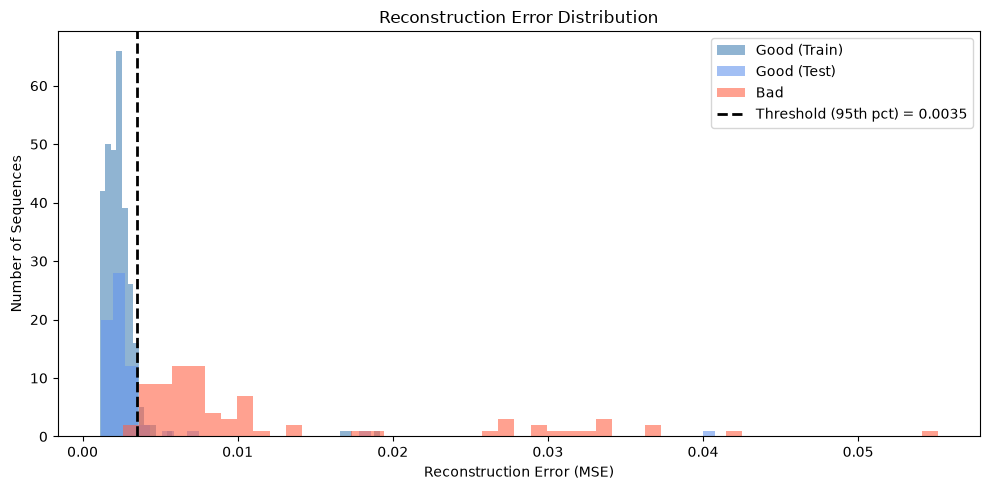

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors,      bins=50, alpha=0.6, label='Good (Train)',  color='steelblue')
ax.hist(test_good_errors,  bins=50, alpha=0.6, label='Good (Test)',   color='cornflowerblue')
ax.hist(bad_errors,        bins=50, alpha=0.6, label='Bad',           color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}th pct) = {threshold:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Number of Sequences')
ax.set_title('Reconstruction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## Evaluation

We combine held-out test sequences (good) with bad sequences:
- **Label 0** = good (error <= threshold)
- **Label 1** = bad (error > threshold)

| Metric | Meaning |
|---|---|
| **Recall (bad)** | How many bad strokes do we catch? |
| **Precision (bad)** | How often are we right when we say 'bad'? |
| **ROC-AUC** | Separability independent of the threshold |


ROC-AUC: 0.9599  (threshold-independent)

  Run 1: 95th-pct baseline  (Threshold = 0.003540)
              precision    recall  f1-score   support

        Good       0.98      0.91      0.94        66
         Bad       0.93      0.99      0.96        79

    accuracy                           0.95       145
   macro avg       0.96      0.95      0.95       145
weighted avg       0.95      0.95      0.95       145

  Run 2: F1-optimal  (Threshold = 0.003622)
              precision    recall  f1-score   support

        Good       0.97      0.92      0.95        66
         Bad       0.94      0.97      0.96        79

    accuracy                           0.95       145
   macro avg       0.95      0.95      0.95       145
weighted avg       0.95      0.95      0.95       145



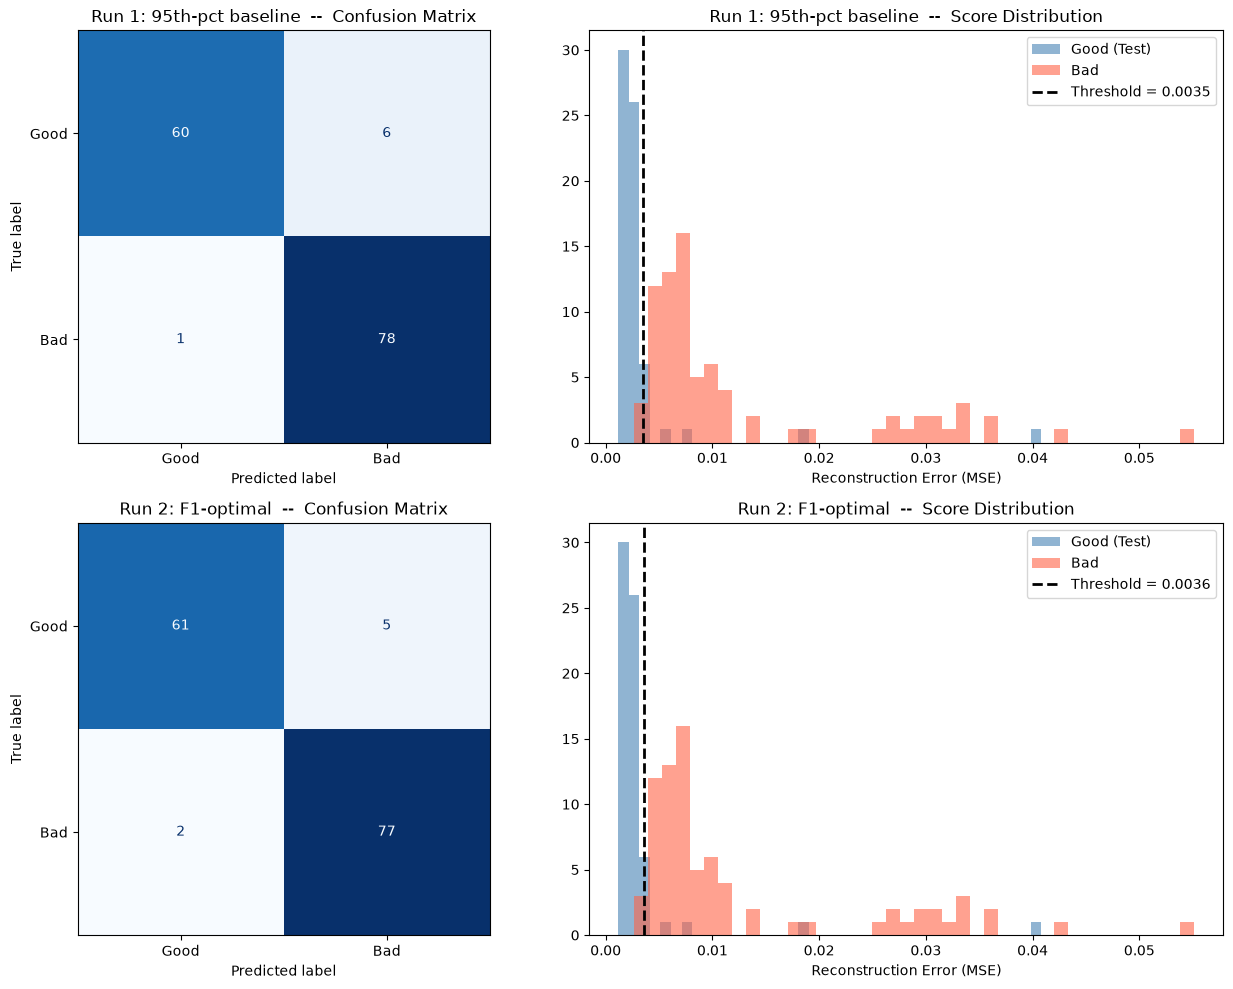

In [83]:
y_scores = np.concatenate([test_good_errors, bad_errors])
y_true   = np.array([0] * len(test_good_errors) + [1] * len(bad_errors))

precision_c, recall_c, thr_c = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_c         = 2 * (precision_c * recall_c) / (precision_c * recall_c + 1e-8)
threshold_f1 = thr_c[np.argmax(f1_c)]

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}  (threshold-independent)\n')

configs = [
    ('95th-pct baseline', threshold),
    ('F1-optimal',        threshold_f1),
]

sep = '=' * 50
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, (label, thr) in enumerate(configs):
    y_pred = (y_scores > thr).astype(int)

    print(sep)
    print(f'  Run {i+1}: {label}  (Threshold = {thr:.6f})')
    print(sep)
    print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Good', 'Bad']
    ).plot(ax=axes[i, 0], colorbar=False, cmap='Blues')
    axes[i, 0].set_title(f'Run {i+1}: {label}  --  Confusion Matrix')

    axes[i, 1].hist(test_good_errors, bins=40, alpha=0.6, label='Good (Test)', color='steelblue')
    axes[i, 1].hist(bad_errors,       bins=40, alpha=0.6, label='Bad',         color='tomato')
    axes[i, 1].axvline(thr, color='black', linestyle='--', linewidth=2,
                       label=f'Threshold = {thr:.4f}')
    axes[i, 1].set_xlabel('Reconstruction Error (MSE)')
    axes[i, 1].set_title(f'Run {i+1}: {label}  --  Score Distribution')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


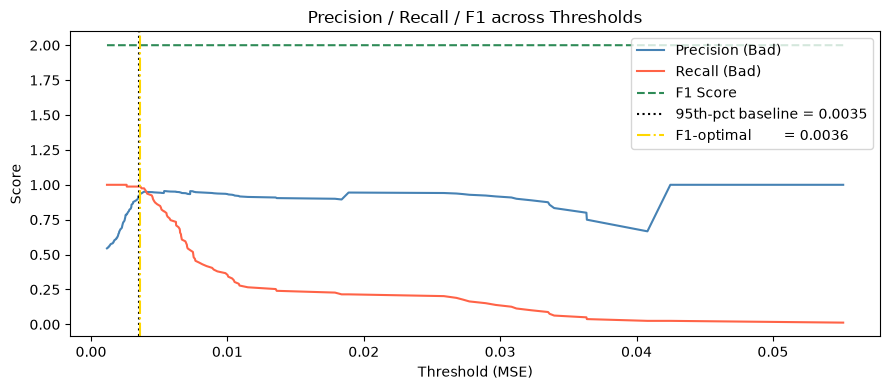

In [84]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thr_c, precision_c[:-1], label='Precision (Bad)', color='steelblue')
ax.plot(thr_c, recall_c[:-1],    label='Recall (Bad)',    color='tomato')
ax.plot(thr_c, f1_c[:-1],        label='F1 Score',        color='seagreen', linestyle='--')
ax.axvline(threshold,     color='black', linestyle=':',
           label=f'95th-pct baseline = {threshold:.4f}')
ax.axvline(threshold_f1,  color='gold',  linestyle='-.',
           label=f'F1-optimal        = {threshold_f1:.4f}')
ax.set_xlabel('Threshold (MSE)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 across Thresholds')
ax.legend()
plt.tight_layout()
plt.show()


In [85]:
print('=' * 60)
print('  SUMMARY')
print('=' * 60)
print(f'\n  ROC-AUC: {auc:.4f}  (threshold-independent)\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')

for label, thr in [('95th-pct baseline', threshold), ('F1-optimal', threshold_f1)]:
    y_pred = (y_scores > thr).astype(int)
    rep = classification_report(y_true, y_pred, target_names=['Good', 'Bad'], output_dict=True)
    p   = rep['Bad']['precision']
    r   = rep['Bad']['recall']
    f1  = rep['Bad']['f1-score']
    print(f'  {label:22}  {thr:>10.6f}  {p:>10.2%}  {r:>8.2%}  {f1:>6.4f}')

print('=' * 60)


  SUMMARY

  ROC-AUC: 0.9599  (threshold-independent)

                           Threshold   Precision    Recall      F1
  ----------------------  ----------  ----------  --------  ------
  95th-pct baseline         0.003540      92.86%    98.73%  0.9571
  F1-optimal                0.003622      93.90%    97.47%  0.9565


---

## Hyperparameter Tuning with Optuna

Optuna automatically searches for the best combination of:

| Hyperparameter | Search Space |
|---|---|
| `latent_dim` | 8, 16, 32, 64 |
| `lstm_units` | 64, 128, 256 |
| `dropout` | 0.0 - 0.4 |
| `lr` | 1e-4 - 1e-2 (log) |

**Objective metric**: ROC-AUC on test (good) + bad strokes (maximize).  
30 trials, ~50 epochs each with early stopping.


In [86]:
def objective(trial):
    latent_dim = trial.suggest_categorical('latent_dim', [8, 16, 32, 64])
    lstm_units = trial.suggest_categorical('lstm_units', [64, 128, 256])
    dropout    = trial.suggest_float('dropout', 0.0, 0.4, step=0.1)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    inputs     = keras.Input(shape=(n_timesteps, n_features))
    x          = layers.LSTM(lstm_units, return_sequences=False)(inputs)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    bottleneck = layers.Dense(latent_dim, activation='relu')(x)
    x          = layers.RepeatVector(n_timesteps)(bottleneck)
    x          = layers.LSTM(lstm_units, return_sequences=True)(x)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)
    m          = keras.Model(inputs, outputs)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')

    m.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )

    def recon_err(X):
        return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

    y_sc = np.concatenate([recon_err(X_test_good), recon_err(X_bad_seq)])
    y_tr = np.array([0] * len(X_test_good) + [1] * len(X_bad_seq))
    return roc_auc_score(y_tr, y_sc)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest trial:  ROC-AUC = {study.best_value:.4f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


Best trial: 24. Best value: 0.965286: 100%|██████████| 30/30 [07:08<00:00, 14.29s/it]


Best trial:  ROC-AUC = 0.9653
  latent_dim: 32
  lstm_units: 256
  dropout: 0.0
  lr: 0.00026973097322071217


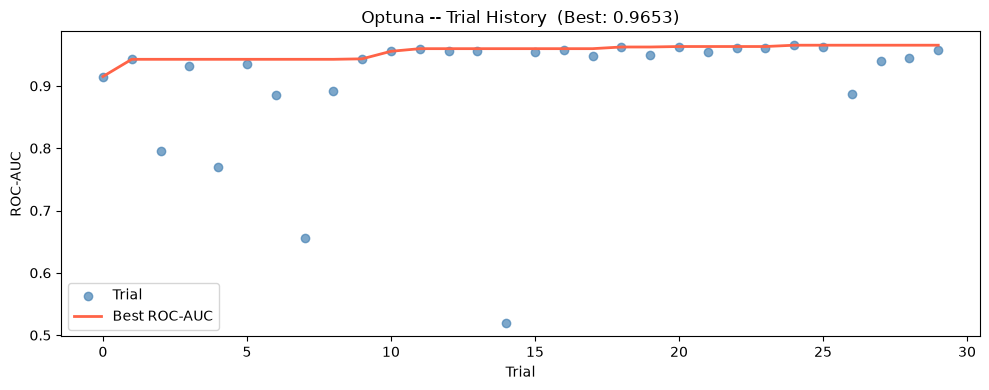


Top-5 Trials:
   value  params_dropout  params_latent_dim  params_lr  params_lstm_units
0.965286             0.0                 32   0.000270                256
0.963176             0.0                 32   0.001113                256
0.962409             0.0                 32   0.000231                256
0.962409             0.0                 32   0.000389                256
0.960683             0.0                 32   0.000507                256


In [87]:
trials_df = study.trials_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trials_df.index, trials_df['value'], alpha=0.7, color='steelblue', label='Trial')
ax.plot(trials_df.index, trials_df['value'].cummax(), color='tomato', linewidth=2, label='Best ROC-AUC')
ax.set_xlabel('Trial')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Optuna -- Trial History  (Best: {study.best_value:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop-5 Trials:')
print(trials_df[['value'] + [c for c in trials_df.columns if c.startswith('params_')]]
      .sort_values('value', ascending=False)
      .head(5)
      .to_string(index=False))


In [88]:
p = study.best_params
print('Best trial:', p, '\n')

inputs     = keras.Input(shape=(n_timesteps, n_features))
x          = layers.LSTM(p['lstm_units'], return_sequences=False)(inputs)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
bottleneck = layers.Dense(p['latent_dim'], activation='relu')(x)
x          = layers.RepeatVector(n_timesteps)(bottleneck)
x          = layers.LSTM(p['lstm_units'], return_sequences=True)(x)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)

best_model = keras.Model(inputs, outputs)
best_model.compile(optimizer=keras.optimizers.Adam(p['lr']), loss='mse')
best_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)

def recon_err(m, X):
    return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

test_good_err_best = recon_err(best_model, X_test_good)
bad_err_best       = recon_err(best_model, X_bad_seq)
y_sc_best          = np.concatenate([test_good_err_best, bad_err_best])
y_tr_best          = np.array([0] * len(test_good_err_best) + [1] * len(bad_err_best))

auc_best           = roc_auc_score(y_tr_best, y_sc_best)

prec_b, rec_b, thr_b = precision_recall_curve(y_tr_best, y_sc_best, pos_label=1)
f1_b        = 2 * (prec_b * rec_b) / (prec_b * rec_b + 1e-8)
thr_f1_best = thr_b[np.argmax(f1_b)]

y_pred_best = (y_sc_best > thr_f1_best).astype(int)
rep_best    = classification_report(y_tr_best, y_pred_best, target_names=['Good', 'Bad'], output_dict=True)

print('\n' + '=' * 60)
print('  BEST MODEL (Optuna)')
print('=' * 60)
print(f'\n  ROC-AUC: {auc_best:.4f}\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')
print(f'  {"F1-optimal":22}  {thr_f1_best:>10.6f}  {rep_best["Bad"]["precision"]:>10.2%}  {rep_best["Bad"]["recall"]:>8.2%}  {rep_best["Bad"]["f1-score"]:>6.4f}')
print('=' * 60)


Best trial: {'latent_dim': 32, 'lstm_units': 256, 'dropout': 0.0, 'lr': 0.00026973097322071217} 

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.5002 - val_loss: 0.2691
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1643 - val_loss: 0.0992
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0932 - val_loss: 0.0874
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0795 - val_loss: 0.0769
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0719 - val_loss: 0.0709
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0660 - val_loss: 0.0654
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0612 - val_loss: 0.0611
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0570 - val_loss: 0.0567
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0515 - val_loss: 0.0471
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0384 - val_loss: 0.0292
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

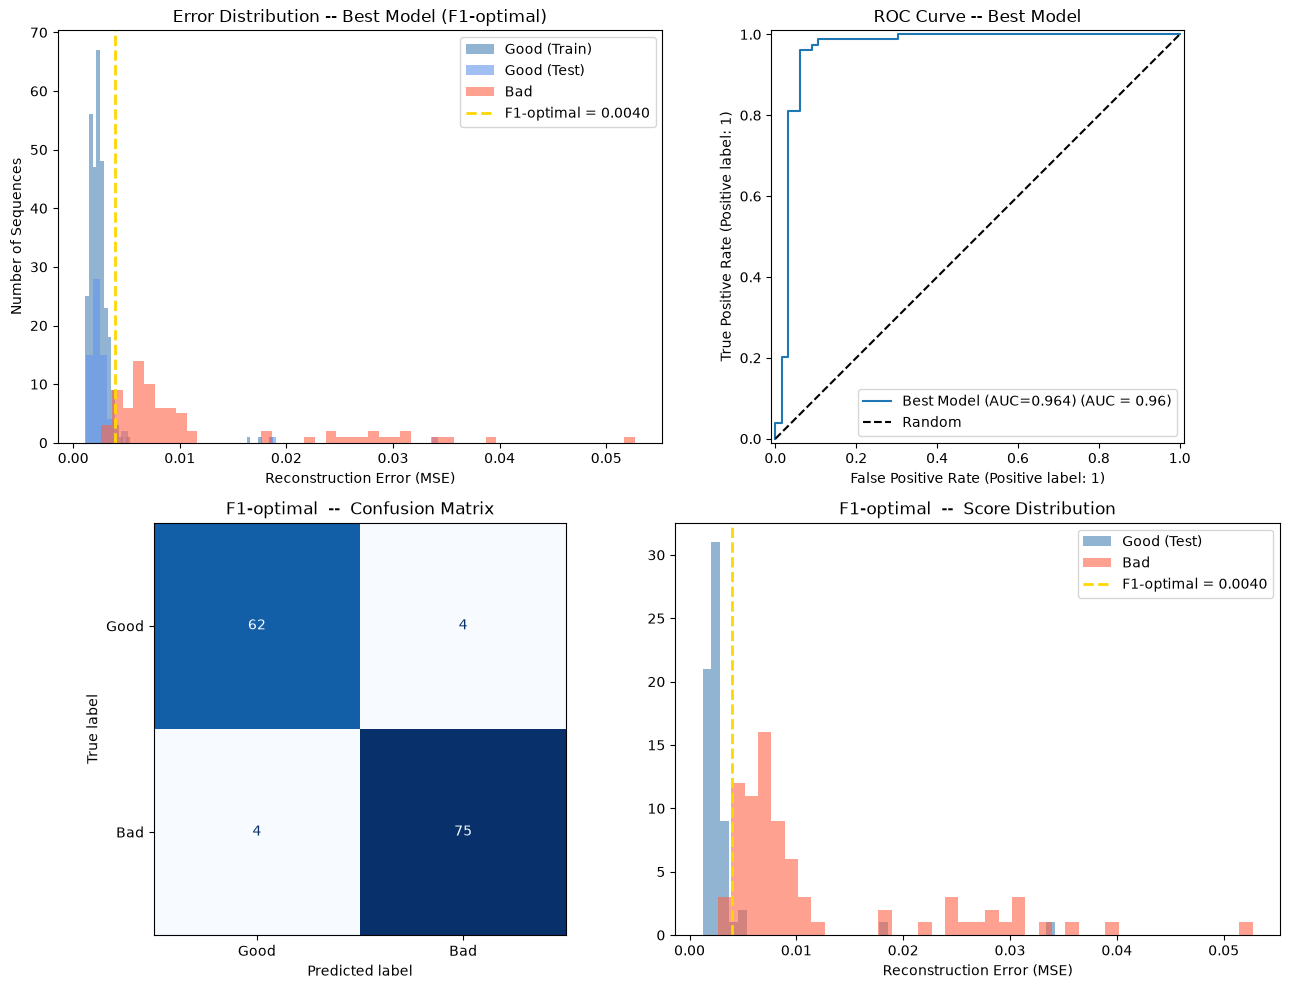

Threshold (F1-optimal): 0.003955
ROC-AUC:                0.9636

              precision    recall  f1-score   support

        Good       0.94      0.94      0.94        66
         Bad       0.95      0.95      0.95        79

    accuracy                           0.94       145
   macro avg       0.94      0.94      0.94       145
weighted avg       0.94      0.94      0.94       145



In [94]:
train_err_best = recon_err(best_model, X_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].hist(train_err_best,     bins=50, alpha=0.6, label='Good (Train)', color='steelblue')
axes[0, 0].hist(test_good_err_best, bins=50, alpha=0.6, label='Good (Test)',  color='cornflowerblue')
axes[0, 0].hist(bad_err_best,       bins=50, alpha=0.6, label='Bad',          color='tomato')
axes[0, 0].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[0, 0].set_xlabel('Reconstruction Error (MSE)')
axes[0, 0].set_ylabel('Number of Sequences')
axes[0, 0].set_title('Error Distribution -- Best Model (F1-optimal)')
axes[0, 0].legend()

RocCurveDisplay.from_predictions(
    y_tr_best, y_sc_best,
    name=f'Best Model (AUC={auc_best:.3f})',
    ax=axes[0, 1]
)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_title('ROC Curve -- Best Model')
axes[0, 1].legend()

ConfusionMatrixDisplay(
    confusion_matrix(y_tr_best, y_pred_best),
    display_labels=['Good', 'Bad']
).plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title('F1-optimal  --  Confusion Matrix')

axes[1, 1].hist(test_good_err_best, bins=40, alpha=0.6, label='Good (Test)', color='steelblue')
axes[1, 1].hist(bad_err_best,       bins=40, alpha=0.6, label='Bad',         color='tomato')
axes[1, 1].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[1, 1].set_xlabel('Reconstruction Error (MSE)')
axes[1, 1].set_title('F1-optimal  --  Score Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

y_pred_f1 = (y_sc_best > thr_f1_best).astype(int)
tn, fp, fn, tp = confusion_matrix(y_tr_best, y_pred_f1).ravel()

print(f'Threshold (F1-optimal): {thr_f1_best:.6f}')
print(f'ROC-AUC:                {auc_best:.4f}\n')
print(classification_report(y_tr_best, y_pred_f1, target_names=['Good', 'Bad']))